# Agentic Decisions into RAG Pipelines

The system dynamically decides whether to rely on retrieved documents or perform live web research depending on the quality of retrieved information.

In [1]:
import os 
from typing import List, Dict
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage 
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
#from langchain_chroma import Chroma
#from langchain_community.document_loaders import PyPDFLoader
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import MessagesState
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from tavily import TavilyClient


from dotenv import load_dotenv
load_dotenv("/Users/oasis/Udacity AI Masters/Agentic/Code/.env")


True

### Setting up the Vector Store
* Documents are loaded into a Chroma vector database.
* Embeddings are generated and stored.

In [2]:
#!pip install langchain-chroma
#!pip install langchain-community
#!pip install pypdf

from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader


embeddings_fn = OpenAIEmbeddings(
    model="text-embedding-3-large"
)


vector_store = Chroma(
    collection_name="agnetic_ai",
    embedding_function=embeddings_fn
)


file_path = "compact-guide-to-large-language-models.pdf"
loader = PyPDFLoader(file_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(pages)

_ = vector_store.add_documents(documents=all_splits)


/var/folders/ws/1hfjcgys5mx889l7xsvl7zpw0000gn/T/ipykernel_18680/599061433.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


### Setting up workflow

In [3]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
)

In [4]:
class State(MessagesState):
    question: str
    documents: List[Document]
    search_required: str = "NO"
    answer: str


def retrieve(state: State):
    question = state["question"]
    retrieved_docs = vector_store.similarity_search(question)
    return {"documents": retrieved_docs}


def evaluator(state: State):
    question = state["question"]
    documents = state["documents"]
    docs_content = "\n\n".join(doc.page_content for doc in documents)
    
    template = ChatPromptTemplate([
        ("system", "You are an assistant for evaluating context."),
        ("human", "Use the following pieces of retrieved context to determine if an " 
                  "additional search is required. If the context is relevant to the " 
                  "question, your response should be 'NO', i.e. no need for search. "
                  "If the context is not relevant, say 'YES', i.e. search the web for an answer. " 
                  "Don't explain anything, if it's to search the web, say YES, otherwise, NO. "
                  "\n# Question: \n-> {question} "
                  "\n# Context: \n-> {context} "
                  "\n# Answer: "),
    ])

    chain = template | llm | StrOutputParser()

    search_required = chain.invoke(
        {"context": docs_content, "question": question}
    )

    return {"search_required": search_required}




In [5]:
@tool
def web_search(question:str)->Dict:
    """
    Return top search results for a given search query
    """
    tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    response = tavily_client.search(question)
    return response

In [6]:
llm_with_tools = llm.bind_tools([web_search])

In [7]:
def researcher(state: State):
    question = state["question"]
    messages = state["messages"]
    if not messages:
        human_message = HumanMessage(
            "Conduct a web research to findout the answer to the following question: "
            f"```{question}```"
        )
        messages = [human_message]
    
    ai_message = llm_with_tools.invoke(messages)
    messages.append(ai_message)
    return {"messages": messages, "answer": ai_message.content}

In [8]:
def augment(state: State):
    question = state["question"]
    documents = state["documents"]
    docs_content = "\n\n".join(doc.page_content for doc in documents)
    
    template = ChatPromptTemplate([
        ("system", "You are an assistant for question-answering tasks."),
        ("human", "Use the following pieces of retrieved context to answer the question. "
                "If you don't know the answer, just say that you don't know. " 
                "Use three sentences maximum and keep the answer concise. "
                "\n# Question: \n-> {question} "
                "\n# Context: \n-> {context} "
                "\n# Answer: "),
    ])

    messages = template.invoke(
        {"context": docs_content, "question": question}
    ).to_messages()

    return {"messages": messages}

In [9]:
def generate(state: State):
    ai_message = llm.invoke(state["messages"])
    return {"answer": ai_message.content, "messages": ai_message}

In [10]:
def rag_router(state: State):
    search_required = state["search_required"]
    if search_required.strip().lower() == "yes":
        return "researcher"

    return "augment"

In [11]:
def tool_router(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "web_search"

    return END

In [12]:
workflow = StateGraph(State)

workflow.add_node("retrieve", retrieve)
workflow.add_node("augment", augment)
workflow.add_node("generate", generate)
workflow.add_node("evaluator", evaluator)
workflow.add_node("researcher", researcher)
workflow.add_node("web_search", ToolNode([web_search]))

workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "evaluator")

workflow.add_conditional_edges(
    source="evaluator", 
    path=rag_router, 
    path_map=["augment", "researcher"]
)

workflow.add_conditional_edges(
    source="researcher", 
    path=tool_router, 
    path_map=["web_search", END]
)
workflow.add_edge("web_search", "researcher")

workflow.add_edge("augment", "generate")
workflow.add_edge("generate", END)

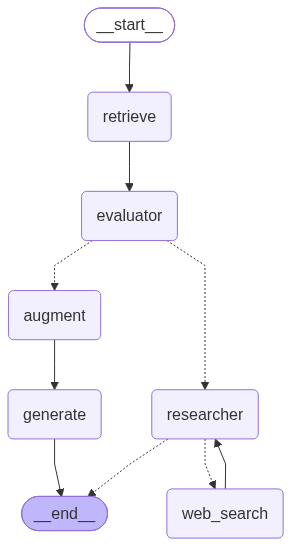

In [13]:
graph = workflow.compile()
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [14]:
output = graph.invoke(
    input={"question": "What is Pokemon?"},
)

In [15]:
output

{'messages': [HumanMessage(content='Conduct a web research to findout the answer to the following question: ```What is Pokemon?```', additional_kwargs={}, response_metadata={}, id='bf24f4c6-3a50-472d-8144-28403f399e10'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 67, 'total_tokens': 84, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a9d97c6db', 'id': 'chatcmpl-EQPDumbQVk3hCIE4M7BNVnZDOX9Hs', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0c20f-8cb8-7492-9d23-c66ae281a603-0', tool_calls=[{'name': 'web_search', 'args': {'question': 'What is Pokemon?'}, 'id': 'call_WrQfLAt91

In [16]:
for message in output["messages"]:
    message.pretty_print()

================================ Human Message =================================

Conduct a web research to findout the answer to the following question: ```What is Pokemon?```
================================== Ai Message ==================================
Tool Calls:
  web_search (call_WrQfLAt91TgVnUaUgAbDPx3Q)
 Call ID: call_WrQfLAt91TgVnUaUgAbDPx3Q
  Args:
    question: What is Pokemon?
================================= Tool Message =================================
Name: web_search

{"query": "What is Pokemon?", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://sg.portal-pokemon.com/about", "title": "What is Pokémon? | The official Pokémon Website in Singapore", "content": "Philippines\n\nWhile Pokémon is a global phenomenon, it also focuses on being locally oriented, working with local communities in various countries and regions to hold events, collaborate with multiple brands and corporations, and serve as a bridge between cultures.   \n  \

In [17]:
output["search_required"]

'YES'

In [18]:
output = graph.invoke(
    input={"question": "What is Open Source model?"},
)

In [19]:
output["search_required"]

'NO'

In [20]:
for message in output["messages"]:
    message.pretty_print()

================================ System Message ================================

You are an assistant for question-answering tasks.
================================ Human Message =================================

Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise. 
# Question: 
-> What is Open Source model? 
# Context: 
-> 7
A Compact Guide to Large Language Models
It does currently take a little bit more work to grab an open source model and 
start using it, but progress is moving very quickly to make them more accessible 
to users. On Databricks, for example, we’ve made improvements to open source 
frameworks like MLflow to make it very easy for someone with a bit of Python 
experience to pull any Hugging Face transformer model and use it as a Python 
object. Oftentimes, you can find an open source model that solves your specific 
problem that is or